# Módulo 6 sesión 2 clase Viernes 25/07
1. Nivel de Ajuste de un Modelo y Tipos de Error
Nivel de Ajuste: Se refiere a qué tan bien un modelo representa los datos.

Tipos de Error:

Error de Entrenamiento: La diferencia entre las predicciones del modelo y los valores reales usando los datos con los que el modelo fue entrenado.

Error de Generalización (o de Test): La diferencia entre las predicciones del modelo y los valores reales usando datos nuevos, no vistos por el modelo. Es la medida más importante para evaluar el rendimiento real del modelo.

Tipos de Ajuste:

Sobreajuste (Overfitting): El modelo es demasiado complejo y se ha "memorizado" los datos de entrenamiento. Tiene un error de entrenamiento bajo, pero un error de generalización alto.

Subajuste (Underfitting):): El modelo es demasiado simple y no ha capturado la relación subyacente en los datos. Tiene un error de entrenamiento y de generalización altos.

Ajuste Apropiado: El modelo encuentra un buen equilibrio entre complejidad y simplicidad, logrando un error de generalización bajo.

2. Trade-off entre Sesgo y Varianza
El Trade-off entre sesgo y varianza es un concepto fundamental en el aprendizaje automático para entender por qué los modelos pueden tener un mal rendimiento.

Sesgo (Bias): Es la diferencia entre la predicción promedio del modelo y el valor real.

Un sesgo alto significa que el modelo es demasiado simple (subajuste) y no puede capturar la relación entre las variables.

Varianza (Variance): Es la variabilidad de la predicción de un modelo para un punto de datos dado.

Una varianza alta significa que el modelo es demasiado sensible a los datos de entrenamiento (sobreajuste). El modelo predice de manera muy diferente para ligeras variaciones en los datos.

El objetivo es encontrar un modelo que tenga un sesgo bajo y una varianza baja simultáneamente, lo cual es el punto óptimo para un buen ajuste.

3. Validación Cruzada
La validación cruzada es una técnica para evaluar el rendimiento de un modelo en datos nuevos y evitar el sobreajuste.

Método de Retención (Hold-out): Se divide el conjunto de datos en dos subconjuntos: uno para entrenamiento y otro para validación. Es el método más simple, pero el rendimiento puede depender de cómo se dividan los datos.

Validación Cruzada de k-Iteraciones (k-Fold Cross-Validation): Se divide el conjunto de datos en k subconjuntos (o "folds"). El modelo se entrena k veces, usando cada vez un fold diferente como conjunto de validación y los k-1 restantes para entrenamiento. El rendimiento final es el promedio de los resultados de las k iteraciones.

Validación Cruzada Dejando Uno Afuera (Leave-One-Out Cross-Validation - LOOCV): Un caso especial de k-Fold donde k es igual al número de muestras. Se entrena el modelo n veces, usando n-1 muestras para entrenamiento y una única muestra para validación. Es computacionalmente costoso, pero muy preciso para conjuntos de datos pequeños.

Muestreo Aleatorio (Random Subsampling): Se realizan múltiples divisiones aleatorias de los datos en conjuntos de entrenamiento y prueba. A diferencia de k-Fold, las iteraciones pueden tener conjuntos de prueba superpuestos.


In [ ]:
# Módulo 6 sesión 2 clase Viernes 25/07
# 1. Tipos de error de un modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Simulamos valores reales y predichos
y_true = [3.0, -0.5, 2.0, 7.0]
y_pred = [2.5, 0.0, 2.1, 7.8]

print("Error Absoluto Medio (MAE):", mean_absolute_error(y_true, y_pred))
print("Error Cuadrático Medio (MSE):", mean_squared_error(y_true, y_pred))
print("Coeficiente de determinación (R²):", r2_score(y_true, y_pred))

Error Absoluto Medio (MAE): 0.475
Error Cuadrático Medio (MSE): 0.2874999999999999
Coeficiente de determinación (R²): 0.9605995717344754


1. Error Absoluto Medio (MAE): 0.475
¿Qué significa?
Es el promedio de los errores absolutos entre los valores reales y los valores predichos por el modelo.

Interpretación:
En promedio, las predicciones del modelo difieren de los valores reales en 0.475 unidades.

Valor ideal:
Cuanto más cercano a 0, mejor el modelo.

2. Error Cuadrático Medio (MSE): 0.2875
¿Qué significa?
Es el promedio de los errores al cuadrado entre las predicciones y los valores reales.

Interpretación:
Un valor de 0.2875 indica que, en promedio, las predicciones del modelo tienen un error cuadrático leve.

Comparación con MAE:
El MSE penaliza más los errores grandes, mientras que el MAE es más robusto frente a valores atípicos.

3. Coeficiente de determinación (R²): 0.9606
¿Qué significa?
Representa la proporción de la varianza de la variable dependiente que puede ser explicada por el modelo.

Interpretación:
Un R² de 0.9606 significa que el 96.06% de la variabilidad de los datos es explicada por el modelo.
Solo el 3.94% se debe a factores no explicados o errores.

Valor ideal:
Mientras más cerca de 1, mejor el ajuste del modelo. Un valor de 0.96 es excelente.

Conclusión general
El modelo tiene:

Muy buen ajuste (R² ≈ 0.96).

Errores relativamente bajos (MAE ≈ 0.47, MSE ≈ 0.29).
Esto indica que el modelo predice con gran precisión y es altamente confiable para el conjunto de datos utilizado.

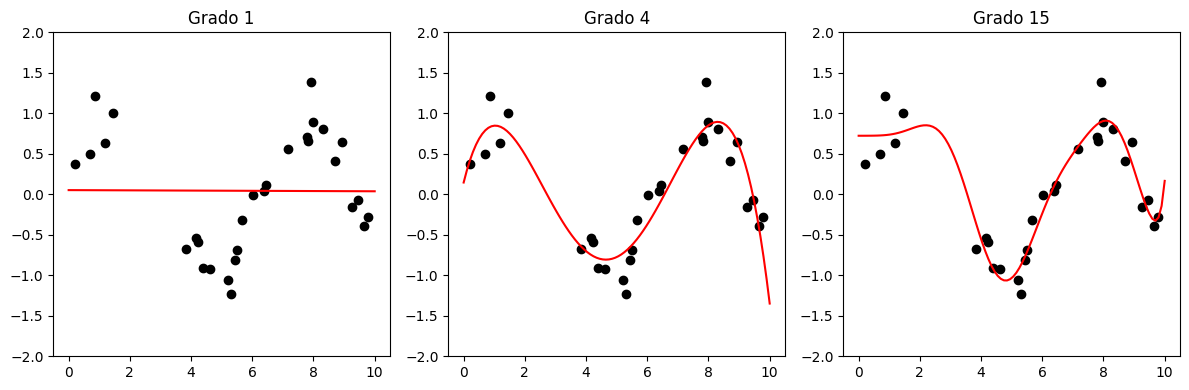

In [ ]:
# 2. Sobreajuste, subajuste y ajuste apropiado
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Generamos datos con ruido
np.random.seed(0)
X = np.sort(np.random.rand(30, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# Modelos con diferentes grados de complejidad
degrees = [1, 4, 15]

plt.figure(figsize=(12, 4))
for i, d in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X, y)
    X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.subplot(1, 3, i + 1)
    plt.scatter(X, y, color='black')
    plt.plot(X_plot, y_plot, color='red')
    plt.title(f"Grado {d}")
    plt.ylim(-2, 2)

plt.tight_layout()
plt.show()
# Grado 1: Subajuste
# Grado 4: Buen ajuste
# Grado 15: Sobreajuste

Interpretación de los tres gráficos:
Grado 1 (izquierda):
Descripción: Es un modelo lineal (una línea recta).

Interpretación:

El modelo no captura bien la forma real de los datos.

Este caso representa un subajuste (underfitting): el modelo es demasiado simple para la estructura real de los datos.

Resultado: errores altos y baja capacidad predictiva.

Grado 4 (centro):
Descripción: Modelo polinomial de grado 4.

Interpretación:

El modelo sigue razonablemente la forma general de los datos.

Captura la tendencia no lineal sin exagerar los extremos.

Es un ejemplo de ajuste apropiado (good fit), donde el sesgo y la varianza están equilibrados.

Este modelo probablemente tenga un buen desempeño predictivo en nuevos datos.

Grado 15 (derecha):
Descripción: Modelo polinomial de grado 15.

Interpretación:

El modelo pasa por muchos puntos de los datos de entrenamiento, generando oscilaciones fuertes.

Se trata de un sobreajuste (overfitting): el modelo es demasiado complejo, adapta ruido y variabilidad aleatoria.

Aunque puede tener error bajo en el entrenamiento, fallará al predecir nuevos datos.

Conclusión general:
Estos gráficos ilustran el trade-off entre sesgo y varianza:

Grado 1: alto sesgo, baja varianza → subajuste.

Grado 4: sesgo y varianza balanceados → buen ajuste.

Grado 15: bajo sesgo, alta varianza → sobreajuste.

In [ ]:
# 3. Trade-off entre sesgo y varianza
# Ya se vió en el ejemplo anterior: modelos simples tienen alto sesgo, complejos tienen alta varianza.

# 4. Validación cruzada
# a) Método de retención (train-test split)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# divide los datos en conjuntos de entrenamiento y prueba
# X_train, y_train: datos de entrenamiento (70%)
# X_test, y_test: datos de prueba (30%)

# b) K-fold cross-validation
from sklearn.model_selection import cross_val_score

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print("Errores de validación cruzada (5-fold):", -scores)
print("Error promedio:", -np.mean(scores))

# c) Validación cruzada aleatoria (ShuffleSplit)
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
print("R² en validación cruzada aleatoria:", scores)

# d) Leave-One-Out (LOOCV)
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
scores = cross_val_score(model, X, y, cv=loo, scoring='neg_mean_squared_error')
print("Error promedio LOOCV:", -np.mean(scores))
# Errores de validación cruzada (5-fold):
# Estos son los errores de validación (probablemente Error Cuadrático Medio, MSE) obtenidos en cada uno de los 5 folds.
# El modelo fue entrenado y evaluado 5 veces, dividiendo los datos en distintas particiones.
# Hay alta variabilidad entre los valores: algunos errores son grandes (4.12), otros pequeños (0.14), lo que sugiere inestabilidad en el modelo.

# Error promedio del 5-fold CV:
# Es el promedio de los errores anteriores.
# Representa una medida general del desempeño del modelo usando validación cruzada.
# Cuanto menor, mejor, pues indica menor error de predicción en promedio.
# Sin embargo, el valor es influenciado por la alta dispersión de los errores individuales.

# R² en validación cruzada aleatoria (probablemente Monte Carlo CV):
# Estos valores corresponden al coeficiente de determinación R² por iteración.
#Todos los valores son negativos, lo que indica que el modelo predice peor que una línea horizontal (modelo constante con la media).
# Esto suele pasar si:

# Hay sobreajuste o subajuste.
# El modelo no generaliza bien a nuevos datos.
# Hay poca muestra o alta varianza en las divisiones aleatorias.

# Error promedio LOOCV:
# Se refiere al Leave-One-Out Cross-Validation.

# Se entrena con n−1 datos y se prueba con 1, repitiendo esto para todos los datos.

# El resultado es el error promedio de todos esos pasos.
# Suele ser más estable y menos sesgado, pero computacionalmente costoso.
# En este caso, el error es más bajo que el del 5-fold CV, lo que podría indicar:
# El modelo generaliza algo mejor con más datos de entrenamiento (n-1).
# Pero aún así puede estar fallando en generalización, si se compara con el bajo R².

# Conclusión general:
# El modelo parece inestable y posiblemente mal ajustado (o mal especificado).
# Hay alta varianza en los errores, y el R² negativo sugiere mal desempeño en predicciones.
# El resultado de LOOCV mejora un poco, pero sigue mostrando señales de bajo poder predictivo.







Errores de validación cruzada (5-fold): [4.12005371 1.48974117 0.2919484  1.3849816  0.1420967 ]
Error promedio: 1.4857643176988904
R² en validación cruzada aleatoria: [-0.41367724 -0.50134065 -0.79650279 -0.09619619 -0.62540823]
Error promedio LOOCV: 0.5830877453776335


In [ ]:
# Segunda parte
# Ejemplo 1: Demostración de Overfitting y Underfitting
# Este código simula datos para mostrar visualmente el sobreajuste y el subajuste utilizando modelos de regresión polinómica.
# 1. Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline # # Para encadenar transformaciones y estimadores (útil para combinar PolynomialFeatures y LinearRegression)
from sklearn.preprocessing import PolynomialFeatures # # Para transformar los datos de entrada a características polinómicas
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 2. Generar datos de ejemplo (con un poco de ruido)
np.random.seed(0)
n_samples = 100
X = np.random.rand(n_samples) * 10 - 5
y = 2 * (X) ** 2 + 3 * X + 10 + np.random.randn(n_samples) * 15
# Generación de la variable independiente X
# np.random.rand(n_samples) genera 100 números aleatorios entre 0 y 1.
# * 10 los escala para que estén entre 0 y 10.
# - 5 los desplaza para que estén entre -5 y 5.
# Así, X contendrá 100 valores distribuidos uniformemente entre -5 y 5.
# y = 2 * (X) ** 2 + 3 * X + 10  -> Esta es una relación cuadrática (parábola).
#                                  Es la relación "ideal" que nuestros modelos intentarán aprender.
# + np.random.randn(n_samples) * 15 -> Añade "ruido" aleatorio a los datos.
#                                    np.random.randn(n_samples) genera 100 números de una
#                                    distribución normal estándar (media 0, desviación estándar 1).
#                                    * 15 lo escala para que el ruido sea más significativo.
#                                    Este ruido simula imperfecciones en los datos reales y hace que
#                                    el problema no sea trivial de resolver.

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Dividir datos en entrenamiento y prueba
# train_test_split es una función crucial para evaluar modelos de machine learning.
# Divide el conjunto total de datos (X, y) en dos subconjuntos:
# - X_train, y_train: Datos utilizados para "entrenar" el modelo.
# - X_test, y_test: Datos utilizados para "probar" el modelo (evaluar su rendimiento con datos no vistos).
# test_size=0.3: Indica que el 30% de los datos se destinarán al conjunto de prueba,
#                y el 70% restante al conjunto de entrenamiento.
# random_state=42: Al igual que np.random.seed, asegura que la división de los datos
#                  sea la misma cada vez que ejecutes el código, garantizando la reproducibilidad.

In [ ]:
# Crear un modelo de Regresión Polinómica
def get_model(degree):
    return Pipeline([
        ('polynomial_features', PolynomialFeatures(degree=degree)),
        ('linear_regression', LinearRegression())
    ])
    # La función 'get_model' toma un argumento 'degree' (grado)
    # que determinará la complejidad del polinomio.
    # Pipeline es una herramienta de scikit-learn que permite encadenar
        # múltiples pasos de procesamiento de datos y un estimador final.
        # Esto es muy útil porque asegura que las transformaciones (como PolynomialFeatures)
        # se apliquen consistentemente tanto al conjunto de entrenamiento como al de prueba,
        # y que el flujo de trabajo sea limpio y reproducible.
        # Aquí, estamos definiendo dos pasos en nuestra tubería (pipeline):
        # ('polynomial_features', PolynomialFeatures(degree=degree)),
        # Este es el primer paso en la tubería.
        # 'PolynomialFeatures' es una clase de scikit-learn que transforma las características
        # de entrada (X, que es una sola columna en nuestro caso) en un conjunto de
        # características polinómicas.
        # Por ejemplo, si 'degree' es 2 y tu X original es [x1], esta transformación
        # creará nuevas características como [1, x1, x1^2].
        # Si 'degree' es 15, creará [1, x1, x1^2, ..., x1^15].
        # El 'degree' es el que controla la "complejidad" de nuestro modelo:
        # - degree=1: Regresión Lineal Simple (linea recta) -> subajuste en este ejemplo.
        # - degree=2: Regresión Cuadrática (parábola) -> buen ajuste porque los datos reales son cuadráticos.
        # - degree=15: Regresión Polinómica de alto grado -> sobreajuste.
        # ('linear_regression', LinearRegression())
        # Este es el segundo y último paso en la tubería.
        # 'LinearRegression' es el modelo de regresión lineal estándar.
        # Aunque estamos generando características polinómicas en el paso anterior,
        # el modelo que se ajusta a estas nuevas características sigue siendo una
        # regresión lineal en términos de los *nuevos* predictores (x, x^2, x^3, etc.).
        # Es decir, estamos ajustando una línea recta en un espacio de características transformado.
        # La combinación de 'PolynomialFeatures' y 'LinearRegression' nos permite
        # ajustar curvas polinómicas a los datos.
        # # Cómo se usa esta función en el código principal:
# model_underfit = get_model(degree=1)  # Crea un modelo polinómico de grado 1 (lineal)
# model_goodfit = get_model(degree=2)   # Crea un modelo polinómico de grado 2 (cuadrático)
# model_overfit = get_model(degree=15)  # Crea un modelo polinómico de grado 15 (muy complejo)

En resumen, esta función get_model(degree) hace lo siguiente:

Define una fábrica de modelos: Es una función que, dado un degree (grado polinómico), te devuelve un modelo de regresión configurado.

Usa Pipeline: Para agrupar dos pasos:

PolynomialFeatures: Este es el paso clave para la regresión polinómica. Transforma tus datos X originales creando nuevas columnas que son potencias de X hasta el degree especificado (ej., X^2, X^3, etc.).

LinearRegression: Una vez que las características son transformadas polinómicamente, un modelo de regresión lineal estándar se ajusta a estas nuevas características. La combinación de ambos es lo que permite que el modelo aprenda una relación curva (polinómica) en lugar de solo una línea recta.

Controla la complejidad: El parámetro degree es lo que nos permite controlar directamente la complejidad del modelo, lo cual es esencial para demostrar el subajuste (demasiado simple, degree=1), el buen ajuste (justo la complejidad adecuada, degree=2 para datos cuadráticos) y el sobreajuste (demasiado complejo, degree=15).

In [ ]:
# 3. Modelos de Overfitting, Underfitting y Ajuste Apropiado
# A. Underfitting (grado 1: línea recta, demasiado simple)
model_underfit = get_model(degree=1)
model_underfit.fit(X_train.reshape(-1, 1), y_train)
# 3. Modelos de Overfitting, Underfitting y Ajuste Apropiado
# Aquí es donde instanciamos y entrenamos nuestros tres modelos,
# cada uno diseñado para mostrar un tipo diferente de ajuste.

# A. Underfitting (grado 1: línea recta, demasiado simple)
# Llamamos a nuestra función 'get_model' con degree=1.
# Esto crea una Pipeline que primero transforma los datos X
# a características polinómicas de grado 1 (es decir, deja X tal cual,
# o añade una constante si no lo hace ya el LinearRegression internamente).
# En esencia, estamos pidiendo un modelo de regresión lineal simple (una línea recta).

# model_underfit = get_model(degree=1)

# Entrenamos el modelo.
# X_train.reshape(-1, 1) se usa para asegurar que X_train tenga la forma
# esperada por scikit-learn (un array 2D donde cada fila es una muestra
# y cada columna es una característica).
# El método .fit() es el que hace que el modelo "aprenda" de los datos de entrenamiento
# (X_train y y_train). En este caso, la regresión lineal ajusta los coeficientes
# de la línea recta para minimizar el error entre sus predicciones y y_train.
# model_underfit.fit(X_train.reshape(-1, 1), y_train)
# Resultado esperado: Este modelo será demasiado simple para capturar la
#                     verdadera relación cuadrática de los datos (y = 2X^2 + 3X + 10).
#                     La línea recta no podrá seguir la curva, por lo que tendrá
#                     un error alto tanto en entrenamiento como en prueba: SUB_AJUSTE.

# B. Ajuste Apropiado (grado 2: la forma real de los datos)
model_goodfit = get_model(degree=2)
model_goodfit.fit(X_train.reshape(-1, 1), y_train)
# B. Ajuste Apropiado (grado 2: la forma real de los datos)
# Llamamos a 'get_model' con degree=2.
# Esto crea una Pipeline que transforma X a características polinómicas de grado 2
# (es decir, incluye X y X^2).
# Este grado 2 coincide con la forma real en que generamos los datos (y = 2X^2 + 3X + 10).
# Por lo tanto, este modelo tiene la complejidad adecuada para capturar la relación subyacente.

# model_goodfit = get_model(degree=2)

# Entrenamos este modelo con los mismos datos de entrenamiento.
# model_goodfit.fit(X_train.reshape(-1, 1), y_train)
# Resultado esperado: Este modelo se ajustará bien a la curva de los datos.
#                     Tendrá un error de entrenamiento relativamente bajo y,
#                     crucialmente, un error de prueba también bajo, lo que
#                     indica un buen rendimiento de generalización: AJUSTE_APROPIADO.

# C. Overfitting (grado 15: demasiado complejo)
model_overfit = get_model(degree=15)
model_overfit.fit(X_train.reshape(-1, 1), y_train)
# C. Overfitting (grado 15: demasiado complejo)
# Llamamos a 'get_model' con degree=15.
# Esto crea una Pipeline que transforma X en características polinómicas hasta el grado 15
# (X, X^2, ..., X^15).
# Un grado tan alto permite que el modelo sea extremadamente flexible y complejo.
# model_overfit = get_model(degree=15)

# Entrenamos este modelo.
# model_overfit.fit(X_train.reshape(-1, 1), y_train)
# Resultado esperado: Debido a su alta complejidad, este modelo intentará pasar
#                     por *todos* los puntos de datos de entrenamiento, incluyendo
#                     el ruido. Esto resultará en un error de entrenamiento muy bajo.
#                     Sin embargo, esta "memorización" del ruido hará que el modelo
#                     sea muy malo al predecir en datos nuevos (X_test), ya que el ruido
#                     es aleatorio y no se repetirá de la misma manera. Esto se reflejará
#                     en un error de prueba alto: SOBRE_AJUSTE.

Pipeline(steps=[('polynomial_features', PolynomialFeatures(degree=15)),
                ('linear_regression', LinearRegression())])

En resumen, esta sección del código:

Crea tres instancias de modelos de regresión polinómica, cada una con un nivel diferente de complejidad (determinado por el degree del polinomio).

Utiliza la función get_model (que a su vez usa Pipeline, PolynomialFeatures y LinearRegression) para construir estos modelos.

Entrena cada uno de estos modelos utilizando el mismo conjunto de datos de entrenamiento (X_train, y_train).

Esta configuración permite comparar directamente cómo la complejidad de un modelo (representada por el grado polinómico) afecta su capacidad para aprender de los datos de entrenamiento y, más importante aún, para generalizar a datos no vistos.

Pipeline (el contenedor superior):

Indica que estás viendo un objeto Pipeline de scikit-learn.

Un Pipeline es una herramienta para encadenar múltiples transformaciones de datos y un estimador final en un solo objeto cohesivo. Esto es extremadamente útil porque garantiza que todos los pasos se apliquen de manera consistente a tus datos de entrenamiento y prueba, y hace que tu código sea más limpio y menos propenso a errores.

La línea Pipeline(steps=[('polynomial_features', PolynomialFeatures(degree=15)), ('linear_regression', LinearRegression())]) es la definición de este pipeline.

steps=[... ]:

Dentro de la definición del Pipeline, steps es una lista de tuplas. Cada tupla representa un paso en el proceso.

Cada tupla tiene dos elementos:

Un nombre de cadena (ej., 'polynomial_features'). Este es solo un identificador que le das a ese paso.

Una instancia de un transformador o estimador de scikit-learn (ej., PolynomialFeatures(degree=15) o LinearRegression()).

('polynomial_features', PolynomialFeatures(degree=15)) (Primer paso del pipeline):

PolynomialFeatures: Este es un transformador. Su función es tomar las características de entrada (X) y crear nuevas características que son potencias de las originales (y sus productos si tuvieras múltiples características de entrada, aunque en tu ejemplo solo tienes una X).

degree=15: Este es el parámetro clave. Significa que PolynomialFeatures generará todas las potencias de X desde 1 hasta 15. Por ejemplo, si tu X original es solo [x], después de esta transformación tendrás características como [1, x, x^2, x^3, ..., x^15].

Significado en el contexto de Overfitting: Un degree=15 es un grado polinómico muy alto. Esto significa que el modelo resultante será extremadamente flexible y podrá crear curvas muy complejas para ajustarse a los datos de entrenamiento, incluyendo el ruido. Es el principal contribuyente al sobreajuste en el ejemplo que estamos analizando.

('linear_regression', LinearRegression()) (Segundo paso del pipeline):

LinearRegression: Este es el estimador final del pipeline. Es un modelo de regresión lineal estándar.

Qué hace: Después de que PolynomialFeatures ha transformado tus características originales en un conjunto de características polinómicas (ej., [1, x, x^2, ..., x^15]), LinearRegression toma estas nuevas características y les ajusta un modelo lineal. La combinación de la transformación polinómica y la regresión lineal es lo que se conoce como regresión polinómica.

In [ ]:
# 4. Evaluación de errores
print("--- Evaluación de Errores ---")
print(f"Modelo Subajustado (grado 1) - MSE de Entrenamiento: {mean_squared_error(y_train, model_underfit.predict(X_train.reshape(-1, 1))):.2f}")
print(f"Modelo Subajustado (grado 1) - MSE de Test: {mean_squared_error(y_test, model_underfit.predict(X_test.reshape(-1, 1))):.2f}")
print("-" * 30)
print(f"Modelo con Buen Ajuste (grado 2) - MSE de Entrenamiento: {mean_squared_error(y_train, model_goodfit.predict(X_train.reshape(-1, 1))):.2f}")
print(f"Modelo con Buen Ajuste (grado 2) - MSE de Test: {mean_squared_error(y_test, model_goodfit.predict(X_test.reshape(-1, 1))):.2f}")
print("-" * 30)
print(f"Modelo Sobreajustado (grado 15) - MSE de Entrenamiento: {mean_squared_error(y_train, model_overfit.predict(X_train.reshape(-1, 1))):.2f}")
print(f"Modelo Sobreajustado (grado 15) - MSE de Test: {mean_squared_error(y_test, model_overfit.predict(X_test.reshape(-1, 1))):.2f}")

--- Evaluación de Errores ---
Modelo Subajustado (grado 1) - MSE de Entrenamiento: 431.84
Modelo Subajustado (grado 1) - MSE de Test: 306.93
------------------------------
Modelo con Buen Ajuste (grado 2) - MSE de Entrenamiento: 240.74
Modelo con Buen Ajuste (grado 2) - MSE de Test: 169.70
------------------------------
Modelo Sobreajustado (grado 15) - MSE de Entrenamiento: 207.24
Modelo Sobreajustado (grado 15) - MSE de Test: 232.71


Modelo Subajustado (grado 1)
Modelo Subajustado (grado 1) - MSE de Entrenamiento: 431.84
Modelo Subajustado (grado 1) - MSE de Test: 306.93
grado 1: Esto significa que el modelo es una línea recta.

MSE de Entrenamiento (431.84): Es bastante alto. Esto indica que el modelo no pudo ajustarse bien a los datos de entrenamiento, ni siquiera a los datos que ya había "visto".

MSE de Test (306.93): También es alto. Esto demuestra que el modelo es malo generalizando a datos nuevos.

Interpretación: Ambos errores son altos, lo cual es la señal clásica de subajuste (underfitting). El modelo es demasiado simple (una línea recta) para capturar la relación cuadrática real en los datos. No tiene la complejidad suficiente para aprender el patrón subyacente, ni siquiera en los datos de entrenamiento.

2. Modelo con Buen Ajuste (grado 2)
Modelo con Buen Ajuste (grado 2) - MSE de Entrenamiento: 240.74
Modelo con Buen Ajuste (grado 2) - MSE de Test: 169.70
grado 2: Esto significa que el modelo es una curva cuadrática (una parábola). Recuerda que generamos los datos con una relación cuadrática subyacente (y = 2 * (X) ** 2 + 3 * X + 10).

MSE de Entrenamiento (240.74): Es significativamente más bajo que el modelo de grado 1. Esto indica que el modelo aprendió bien la relación de los datos de entrenamiento.

MSE de Test (169.70): Este es el valor más importante. Es el más bajo de los tres modelos y está muy cerca del MSE de entrenamiento (e incluso un poco mejor en este caso particular, lo cual puede ocurrir por la aleatoriedad de la división de datos y el ruido). Un MSE de test bajo significa que el modelo generaliza muy bien a datos nuevos.

Interpretación: Este es el escenario de ajuste apropiado. El modelo tiene la complejidad justa para capturar la relación real en los datos sin memorizar el ruido. Esto se refleja en errores de entrenamiento y de test bajos y comparables.

3. Modelo Sobreajustado (grado 15)
Modelo Sobreajustado (grado 15) - MSE de Entrenamiento: 207.24
Modelo Sobreajustado (grado 15) - MSE de Test: 232.71
grado 15: Esto significa que el modelo es una curva polinómica muy compleja, con muchos "giros" y "vueltas".

MSE de Entrenamiento (207.24): Es el más bajo de los tres modelos en el conjunto de entrenamiento. Esto podría parecer bueno a primera vista, ya que indica que el modelo se ajusta extremadamente bien a los datos de entrenamiento. De hecho, está "memorizando" esos datos, incluyendo el ruido.

MSE de Test (232.71): ¡Aquí está el problema! Aunque el MSE de entrenamiento es muy bajo, el MSE de test es significativamente más alto. Esto es la señal clásica de sobreajuste (overfitting). El modelo es tan complejo que ha aprendido el ruido y las peculiaridades aleatorias de los datos de entrenamiento, lo que le impide generalizar correctamente a datos nuevos y no vistos. Su rendimiento en la vida real sería pobre.

Conclusión General de la Evaluación de Errores
Esta tabla de MSEs es la forma numérica de observar el Trade-off entre sesgo y varianza:

Subajuste (grado 1): Alto sesgo (el modelo es demasiado simple) y varianza relativamente baja (no se ajusta mucho al ruido). Mal rendimiento en ambos conjuntos.

Buen Ajuste (grado 2): Bajo sesgo (capta la relación real) y baja varianza (no memoriza el ruido). Excelente rendimiento en ambos conjuntos.

Sobreajuste (grado 15): Bajo sesgo (se ajusta a los datos de entrenamiento casi perfectamente) pero alta varianza (es hipersensible al ruido de los datos de entrenamiento, lo que lo hace inestable y malo para generalizar). Excelente rendimiento en entrenamiento, pero pobre en test.
El objetivo siempre es encontrar el modelo que logre un buen equilibrio, minimizando el error de generalización (MSE de Test). En este caso, el modelo de grado 2 es claramente el ganador.

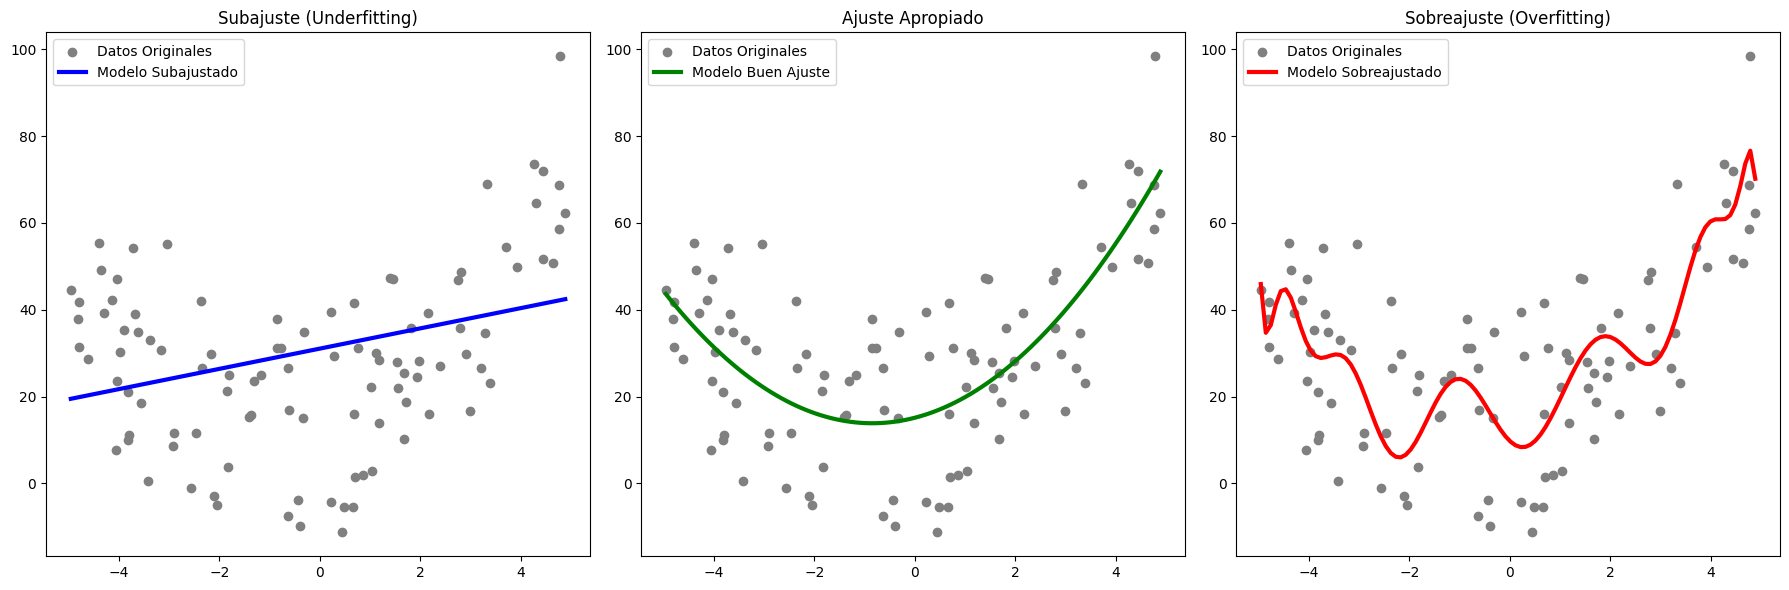

In [ ]:
# 5. Visualización
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color='gray', label='Datos Originales')
plt.plot(X_plot, model_underfit.predict(X_plot), color='blue', lw=3, label='Modelo Subajustado')
plt.title('Subajuste (Underfitting)')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color='gray', label='Datos Originales')
plt.plot(X_plot, model_goodfit.predict(X_plot), color='green', lw=3, label='Modelo Buen Ajuste')
plt.title('Ajuste Apropiado')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color='gray', label='Datos Originales')
plt.plot(X_plot, model_overfit.predict(X_plot), color='red', lw=3, label='Modelo Sobreajustado')
plt.title('Sobreajuste (Overfitting)')
plt.legend()

plt.tight_layout()
plt.show()
# 5. Visualización

# Generar un conjunto de puntos X para trazar las líneas de predicción suaves.
# X_plot: Un array de 100 puntos espaciados uniformemente entre el valor mínimo y máximo de X original.
#         Esto se hace para que las líneas de predicción se vean suaves y continuas en el gráfico.
# .reshape(-1, 1): Se transforma a un array 2D, ya que los modelos de scikit-learn
#                  esperan que las características de entrada estén en este formato.
# X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Crear una figura con un tamaño específico para el gráfico.
# figsize=(18, 6): Define el ancho (18 pulgadas) y alto (6 pulgadas) de la figura.
#                  Un ancho mayor nos permite colocar tres subgráficos uno al lado del otro.
# plt.figure(figsize=(18, 6))

# --- Primer Subgráfico: Subajuste (Underfitting) ---
# plt.subplot(1, 3, 1): Crea una cuadrícula de gráficos (1 fila, 3 columnas) y selecciona
#                       el primer espacio para el gráfico actual.
# plt.subplot(1, 3, 1)
# plt.scatter(X, y, ...): Dibuja los puntos de datos originales.
#                          color='gray': Los puntos se muestran en gris.
#                          label='Datos Originales': Etiqueta para la leyenda.
# plt.scatter(X, y, color='gray', label='Datos Originales')
# plt.plot(X_plot, model_underfit.predict(X_plot), ...): Dibuja la línea de predicción del modelo subajustado.
#                                                          model_underfit.predict(X_plot): El modelo predice
#                                                          los valores de Y para los puntos suaves X_plot.
#                                                          color='blue': La línea se dibuja en azul.
#                                                          lw=3: Grosor de la línea (linewidth).
#                                                          label='Modelo Subajustado': Etiqueta para la leyenda.
# plt.plot(X_plot, model_underfit.predict(X_plot), color='blue', lw=3, label='Modelo Subajustado')
# plt.title(...): Establece el título del subgráfico.
# plt.title('Subajuste (Underfitting)')
# plt.legend(): Muestra las etiquetas definidas en 'label' para cada elemento.
# plt.legend()

# --- Segundo Subgráfico: Ajuste Apropiado ---
# plt.subplot(1, 3, 2): Selecciona el segundo espacio en la cuadrícula de 1x3.
# plt.subplot(1, 3, 2)
# Dibuja los datos originales nuevamente.
# plt.scatter(X, y, color='gray', label='Datos Originales')
# Dibuja la línea de predicción del modelo con buen ajuste (grado 2).
# Esta línea debería seguir de cerca la forma real de los datos.
# plt.plot(X_plot, model_goodfit.predict(X_plot), color='green', lw=3, label='Modelo Buen Ajuste')
# plt.title('Ajuste Apropiado')
# plt.legend()

# --- Tercer Subgráfico: Sobreajuste (Overfitting) ---
# plt.subplot(1, 3, 3): Selecciona el tercer espacio en la cuadrícula de 1x3.
# plt.subplot(1, 3, 3)
# Dibuja los datos originales una vez más.
# plt.scatter(X, y, color='gray', label='Datos Originales')
# Dibuja la línea de predicción del modelo sobreajustado (grado 15).
# Esta línea será muy "nerviosa" o "quebrada", intentando pasar por todos los puntos de datos,
# incluso los ruidosos.
# plt.plot(X_plot, model_overfit.predict(X_plot), color='red', lw=3, label='Modelo Sobreajustado')
# plt.title('Sobreajuste (Overfitting)')
# plt.legend()

# Ajusta automáticamente los parámetros de la subtrama para que quepan en el área de la figura.
# Evita que los títulos o etiquetas se superpongan.
# plt.tight_layout()
# Muestra la figura con todos los subgráficos.
# plt.show()

1. Gráfico de Subajuste (Underfitting)
Imagen:

Título: "Subajuste (Underfitting)"

Puntos Grises: Representan los Datos Originales (X, Y) que simulamos. Observa que estos puntos siguen una tendencia general curva (parabólica), pero con algo de dispersión debido al ruido que se añadió.

Línea Azul: Representa las predicciones de tu Modelo Subajustado (el de grado=1, es decir, una regresión lineal simple).

Interpretación:

La línea azul es recta y plana, lo que indica que el modelo es demasiado simple para capturar la verdadera relación curva (cuadrática) de los datos.

Puedes ver claramente que la línea azul no se ajusta bien a la mayoría de los puntos grises; hay una gran distancia vertical entre la línea y muchos puntos.

Esto es la señal visual de subajuste: el modelo no ha aprendido el patrón subyacente de los datos, lo que se traduce en un alto error tanto en el conjunto de entrenamiento como en el de prueba (como vimos en las métricas de MSE).

2. Gráfico de Ajuste Apropiado
Imagen:

Título: "Ajuste Apropiado"

Puntos Grises: De nuevo, los Datos Originales.

Línea Verde: Representa las predicciones de tu Modelo Buen Ajuste (el de grado=2, que es una regresión polinómica cuadrática).

Interpretación:

La línea verde es una curva (parábola) que sigue de cerca la tendencia general de los puntos grises. Se ajusta muy bien a la forma real de los datos.

Aunque no pasa por todos los puntos (debido al ruido inherente de los datos), minimiza la distancia general a la mayoría de ellos, capturando la relación cuadrática que existe.

Este es el escenario de ajuste apropiado: el modelo tiene la complejidad adecuada para aprender el patrón subyacente sin memorizar el ruido. Esto lleva a un bajo error tanto en entrenamiento como en prueba, lo que indica una buena capacidad de generalización.

3. Gráfico de Sobreajuste (Overfitting)
Imagen:

Título: "Sobreajuste (Overfitting)"

Puntos Grises: Los Datos Originales.

Línea Roja: Representa las predicciones de tu Modelo Sobreajustado (el de grado=15, una regresión polinómica de muy alto grado).

Interpretación:

La línea roja es una curva extremadamente compleja, irregular y "nerviosa", con muchas ondulaciones.

Puedes ver que la línea roja intenta pasar por casi todos los puntos grises, incluso aquellos que son solo ruido aleatorio. El modelo ha "memorizado" la posición exacta de cada punto de datos de entrenamiento.

Esto es la señal visual de sobreajuste: el modelo es demasiado complejo y se ha ajustado demasiado al ruido y a las particularidades específicas del conjunto de entrenamiento. Aunque su error en el conjunto de entrenamiento es muy bajo (porque se ajusta a todo el ruido), su rendimiento en datos nuevos (que tendrían un ruido diferente) sería pobre, lo que se refleja en un MSE de test más alto de lo deseado.

Estos tres gráficos son una excelente manera visual de entender el Trade-off entre Sesgo y Varianza y cómo la complejidad de un modelo (determinada aquí por el grado polinómico) impacta su capacidad para aprender y generalizar.

In [ ]:
# Ejemplo 2: Implementación de Validación Cruzada (k-Fold)
# Este código demuestra cómo utilizar k-Fold Cross-Validation con la librería scikit-learn para evaluar un modelo de clasificación.
# 1. Importar librerías
import numpy as np
from sklearn.model_selection import KFold
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 2. Cargar los datos de Iris
iris = load_iris()
X = iris.data
y = iris.target

# 3. Implementar k-Fold Cross-Validation
# Dividir los datos en 5 folds (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Crear un modelo de Regresión Logística
model = LogisticRegression(max_iter=200)

# Lista para guardar las puntuaciones de precisión de cada fold
accuracy_scores = []
fold_index = 1

# Iterar sobre los folds
for train_index, test_index in kf.split(X):
    # Dividir los datos en conjuntos de entrenamiento y prueba para este fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Hacer predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Calcular la precisión y guardarla
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f"Fold {fold_index}: Precisión = {accuracy:.4f}")
    fold_index += 1

    # 3. Implementar k-Fold Cross-Validation

# Dividir los datos en 5 folds (k=5)
# KFold(n_splits=5, shuffle=True, random_state=42)
# - n_splits=5: Define el número de "folds" (divisiones o subconjuntos) en los que se dividirá el dataset.
#               En este caso, el dataset se dividirá en 5 partes.
# - shuffle=True: Importante. Mezcla los datos antes de dividirlos en folds. Si no se mezcla,
#                 y tus datos están ordenados (por ejemplo, todas las flores de especie 0 primero,
#                 luego todas las de especie 1, etc.), algunos folds podrían no ser representativos
#                 de todas las clases, lo que llevaría a una evaluación sesgada.
# - random_state=42: Asegura que la mezcla (shuffle) sea la misma cada vez que ejecutes el código.
#                    Esto hace que tus resultados sean reproducibles.
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Crear un modelo de Regresión Logística
# Este es el modelo de machine learning que vamos a entrenar y evaluar.
# LogisticRegression es comúnmente usada para problemas de clasificación binaria o multiclase.
# max_iter=200: Un parámetro para el optimizador del modelo, indica el número máximo de iteraciones
#               para que converja. A veces es necesario aumentarlo para evitar advertencias.
# model = LogisticRegression(max_iter=200)

# Lista para guardar las puntuaciones de precisión de cada fold
# Aquí almacenaremos la métrica de evaluación (precisión) obtenida en cada una de las 5 iteraciones.
# accuracy_scores = []
# Contador para imprimir el número de fold actual en la consola.
# fold_index = 1

# Iterar sobre los folds
# kf.split(X) es un generador que produce índices para los conjuntos de entrenamiento y prueba
# para cada "fold" o iteración. En este caso, lo hará 5 veces (una por cada fold).
# train_index: Índices de las filas que se usarán para entrenar el modelo en la iteración actual.
# test_index: Índices de las filas que se usarán para probar el modelo en la iteración actual.
# for train_index, test_index in kf.split(X):
    # Dividir los datos en conjuntos de entrenamiento y prueba para este fold
    # Se usan los índices generados por kf.split() para seleccionar las filas correspondientes
    # de X (características) y y (etiquetas/objetivo).
    # X_train, X_test = X[train_index], X[test_index]
    # y_train, y_test = y[train_index], y[test_index]

    # Entrenar el modelo
    # El modelo se entrena solo con el conjunto de entrenamiento de este fold.
   # model.fit(X_train, y_train)

    # Hacer predicciones en el conjunto de prueba
    # El modelo entrenado hace predicciones sobre el conjunto de prueba (datos no vistos).
   # y_pred = model.predict(X_test)

    # Calcular la precisión y guardarla
    # accuracy_score compara las predicciones del modelo (y_pred) con los valores reales (y_test)
    # del conjunto de prueba.
    # Esta precisión se añade a la lista accuracy_scores.
   # accuracy = accuracy_score(y_test, y_pred)
   # accuracy_scores.append(accuracy)
    # Se imprime la precisión obtenida para el fold actual.
    # print(f"Fold {fold_index}: Precisión = {accuracy:.4f}")
    # fold_index += 1

    # Fold 1: Precisión = 1.0000: En esta iteración, el modelo predijo correctamente el 100% de las instancias en el conjunto de prueba.
# Fold 2: Precisión = 1.0000: Similarmente al Fold 1, el modelo alcanzó una precisión perfecta en este conjunto de prueba.
# Fold 3: Precisión = 0.9333: En este fold, el modelo predijo correctamente aproximadamente el 93.33% de las instancias. Esto significa
# que hubo algunas predicciones incorrectas.
# Fold 4: Precisión = 0.9667: El modelo logró una precisión del 96.67% en este fold.
# Fold 5: Precisión = 0.9667: Similar al Fold 4, con una precisión del 96.67%.
# Interpretación General:
# Los resultados de la validación cruzada k-Fold te dan una idea más robusta del rendimiento de tu modelo que si solo lo evaluaras una vez
# con una única división entrenamiento-prueba.
# Consistencia: Observas que la precisión es consistentemente alta en todos los folds, oscilando entre 0.9333 y 1.0000. Esto sugiere que tu
# modelo es bastante estable y no depende demasiado de la partición específica de los datos que uses para el entrenamiento y la prueba.

Fold 1: Precisión = 1.0000
Fold 2: Precisión = 1.0000
Fold 3: Precisión = 0.9333
Fold 4: Precisión = 0.9667
Fold 5: Precisión = 0.9667


In [ ]:
# 4. Calcular la precisión promedio y la desviación estándar
print("\n--- Resultados Finales de k-Fold ---")
print(f"Precisión Promedio: {np.mean(accuracy_scores):.4f}")
print(f"Desviación Estándar de la Precisión: {np.std(accuracy_scores):.4f}")

# 4. Calcular la precisión promedio y la desviación estándar
# Esta sección toma todas las puntuaciones de precisión que se acumularon
# en la lista 'accuracy_scores' durante el bucle de validación cruzada.

# print("\n--- Resultados Finales de k-Fold ---")
# Esto es simplemente un encabezado para la salida en la consola,
# indicando que lo que sigue es el resumen del proceso de validación cruzada.

# print(f"Precisión Promedio: {np.mean(accuracy_scores):.4f}")
# np.mean(accuracy_scores): Calcula el promedio aritmético de todos los valores
#                           de precisión que se guardaron en la lista 'accuracy_scores'.
#                           Por ejemplo, si los folds dieron precisiones de [0.96, 0.98, 0.95, 0.97, 0.99],
#                           el promedio sería (0.96 + 0.98 + 0.95 + 0.97 + 0.99) / 5.
# {:.4f}: Formatea el número para que tenga 4 decimales.

# print(f"Desviación Estándar de la Precisión: {np.std(accuracy_scores):.4f}")
# np.std(accuracy_scores): Calcula la desviación estándar de las puntuaciones de precisión.
#                          La desviación estándar mide la dispersión o variabilidad de los datos
#                          alrededor de su media.
#                          En este contexto, nos dice qué tan consistentes fueron las precisiones
#                          obtenidas en cada uno de los 5 folds.


--- Resultados Finales de k-Fold ---
Precisión Promedio: 0.9733
Desviación Estándar de la Precisión: 0.0249


Interpretación de los Resultados Finales
Precisión Promedio: 0.9733

Este valor (97.33%) es la estimación más robusta del rendimiento general de tu modelo. Significa que, en promedio, puedes esperar que tu modelo clasifique correctamente el 97.33% de los nuevos datos no vistos.

Al ser un promedio de múltiples entrenamientos y pruebas en diferentes subconjuntos de datos, es una métrica mucho más confiable que si hubieras hecho una sola división entrenamiento/prueba (donde el resultado podría depender mucho de la aleatoriedad de esa división).

Desviación Estándar de la Precisión: 0.0249

Este valor (0.0249 o 2.49%) te indica la consistencia del rendimiento de tu modelo a través de los diferentes folds.

Una desviación estándar baja (como 0.0249 en este caso) significa que las precisiones obtenidas en cada uno de los 5 folds fueron muy similares entre sí. Esto sugiere que el modelo es estable y robusto: su rendimiento no varía drásticamente dependiendo de la parte específica de los datos que se usó para entrenar o probar.

Una desviación estándar alta, por el contrario, indicaría que el rendimiento del modelo es muy variable, lo que podría señalar inestabilidad o que el modelo es muy sensible a los datos específicos de entrenamiento/prueba.

En resumen, los resultados te dicen que tu modelo de Regresión Logística, cuando se evalúa con validación cruzada k-Fold en el dataset de Iris:

Tiene un excelente rendimiento promedio (casi el 97.33% de precisión).

Su rendimiento es muy consistente (baja desviación estándar) a través de diferentes subconjuntos de los datos, lo que lo hace un modelo confiable.

In [ ]:
# Tarea a realizar
# PARTE 1: CARGA Y ANÁLISIS DE LOS DATOS
# Carga de datos.
# 1. Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# 2. Simular los datos
np.random.seed(123)

n = 150
horas_estudio = np.random.normal(15, 4, n)
horas_sueño = np.random.normal(7, 1.2, n)
uso_redes = np.random.normal(3, 1, n)
asistencia = np.random.uniform(60, 100, n)

# Nota final simulada con ruido
nota_final = (
    2.5 * horas_estudio +
    1.0 * horas_sueño -
    1.5 * uso_redes +
    0.4 * asistencia +
    np.random.normal(0, 10, n)
)

# Crear DataFrame
df = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'horas_sueño': horas_sueño,
    'uso_redes': uso_redes,
    'asistencia': asistencia,
    'nota_final': nota_final
})



Ejecuta el código proporcionado para simular los datos de estudiantes con variables como:

Horas de estudio (horas_estudio)

Horas de sueño (horas_sueño)

Uso de redes sociales (uso_redes)

Porcentaje de asistencia a clases (asistencia)

Nota final obtenida (nota_final)

Análisis visual

Elabora un gráfico de pares (pairplot) para observar las relaciones entre variables.

Describe qué variables parecen tener una relación positiva o negativa con la nota final.

PARTE 2: AJUSTE DEL MODELO DE REGRESIÓN (3 puntos)
Construcción del modelo

Ajusta un modelo de regresión lineal múltiple con nota_final como variable dependiente.

Muestra el R² y el Error Cuadrático Medio (MSE) en el conjunto de prueba.

Interpreta los coeficientes del modelo: ¿Qué variable influye más positivamente? ¿Cuál tiene mayor efecto negativo?

Interpretación de ajuste

Según el valor de R², ¿consideras que el modelo tiene un buen ajuste? ¿Por qué?

PARTE 3: VALIDACIÓN CRUZADA Y TRADE-OFF (4 puntos)
Validación cruzada

Aplica validación cruzada K-Fold (con k=5) y reporta los errores MSE.

Calcula el promedio de errores.

¿El modelo es consistente o tiene alta varianza?

Trade-off entre sesgo y varianza

Reflexiona: si aumentamos el número de variables irrelevantes, ¿qué pasaría con el sesgo y la varianza?

¿Qué estrategia usarías para evitar el sobreajuste en este modelo?

PARTE 4: PREGUNTAS DE REFLEXIÓN (extra crédito: 2 puntos)
Explica brevemente qué significa:

Sobreajuste

Subajuste

Validación cruzada

Menciona dos ventajas de usar validación cruzada en vez de una sola división entrenamiento/prueba.

RESULTADOS ESPERADOS DEL CÓDIGO (para verificar):
MSE bajo y R² cercano a 0.8 o más.

Coeficientes: horas_estudio y asistencia con efectos positivos, uso_redes con efecto negativo.

Validación cruzada con errores similares → indica buen ajuste generalizado.